## Why won't BoW or TF-TDF work? 
because there is no relationship in between words so no prediction or sense can be made.
we need a representation of words in numerical values so that we can calculate a relationship.

## What to do?
In order to make the computer understand a written text, we can represent the words as numerical vectors. One way to do so is by Using Word embeddings, they are a way of representing words as numerical vectors. These vectors capture the meaning of the words and their relationships to other words in the language 

Word embeddings can be generated using unsupervised learning algorithms such as Word2vec, GloVe, or FastText. 

Word2vec is a neural network-based method for generating word embeddings, which are dense vector representations of words that capture their semantic meaning and relationships. There are two main approaches to implementing Word2vec:

-> Continuous bag-of-words (CBOW) 

-> Skip-gram

## What is Word Embedding?
Word Embedding is a language modeling technique for mapping words to vectors of real numbers. It represents words or phrases in vector space with several dimensions. Word embeddings can be generated using various methods like neural networks, co-occurrence matrices, probabilistic models, etc. Word2Vec consists of models for generating word embedding. These models are shallow two-layer neural networks having one input layer, one hidden layer, and one output layer.

## What is word2vec 
Word2Vec is a widely used method in natural language processing (NLP) that allows words to be represented as vectors in a continuous vector space. Word2Vec is an effort to map words to high-dimensional vectors to capture the semantic relationships between words, developed by researchers at Google. Words with similar meanings should have similar vector representations, according to the main principle of Word2Vec

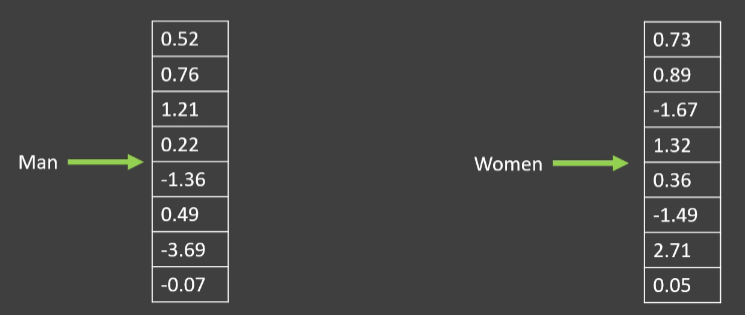

basically the mapping of words in a vector space.
a very popular example is: 

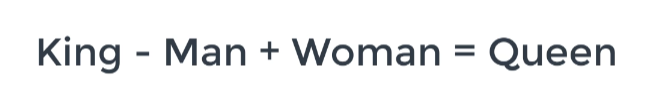  
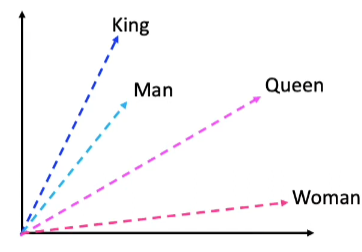 
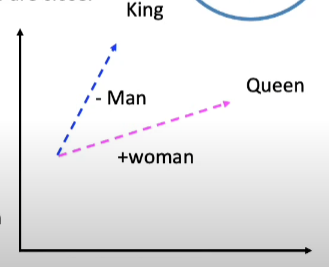

## why use word2vec?
-> preserve relationship 

-> deals with addition of new words in the vocab 
 
-> better results in DL 

mainly in word2vec words that occur in similar context have similar embeddings. 
For example: 

>>>> The kid told that he will be a good technologist 

>>>> The child told that he will be a good technologist 

these two words kid and child do have similar meaning. As a result in word enbedding they will have similar embedding and vectors. So in a large corpus we can use these words as similar meanings, thus reducing the complexity. 


## Continuous Bag of Words (CBOW)

Continuous Bag of Words (CBOW) is a popular natural language processing technique used to generate word embeddings. Word embeddings are important for many NLP tasks because they capture semantic and syntactic relationships between words in a language. CBOW is a neural network-based algorithm that predicts a target word given its surrounding context words. It is a type of “unsupervised” learning, meaning that it can learn from unlabeled data, and it is often used to pre-train word embeddings that can be used for various NLP tasks such as sentiment analysis, text classification, and machine translation. 

In CBoW we predict the target word from the context. 

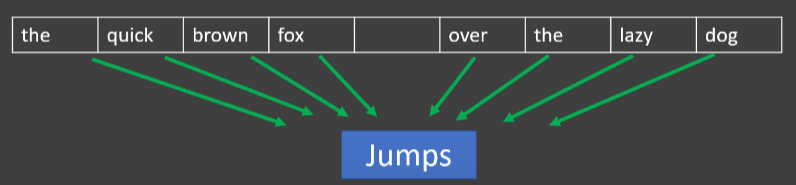 

whereas if we look at Skipgram we predict the context words from target. 

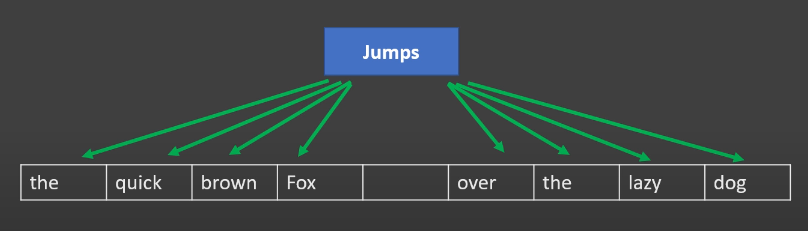

## Architecture 
vector length = number of words in the language 
hot vector for each word = one bit '1' and other bits '0' 

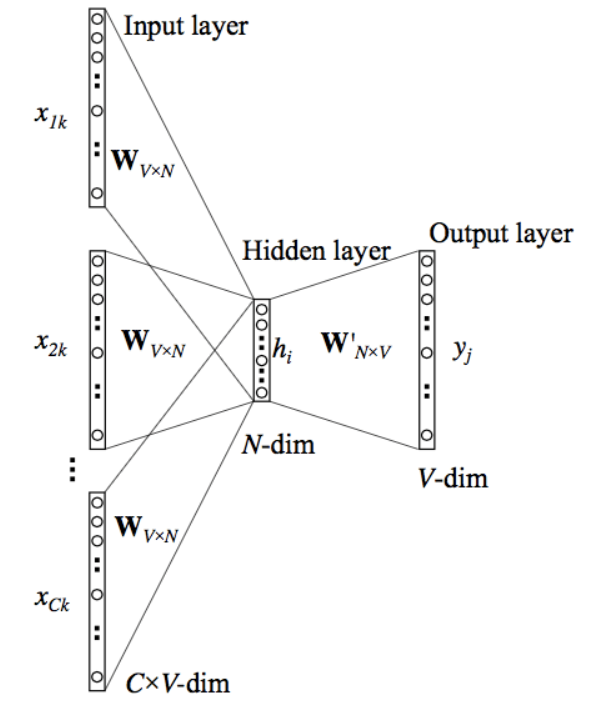 


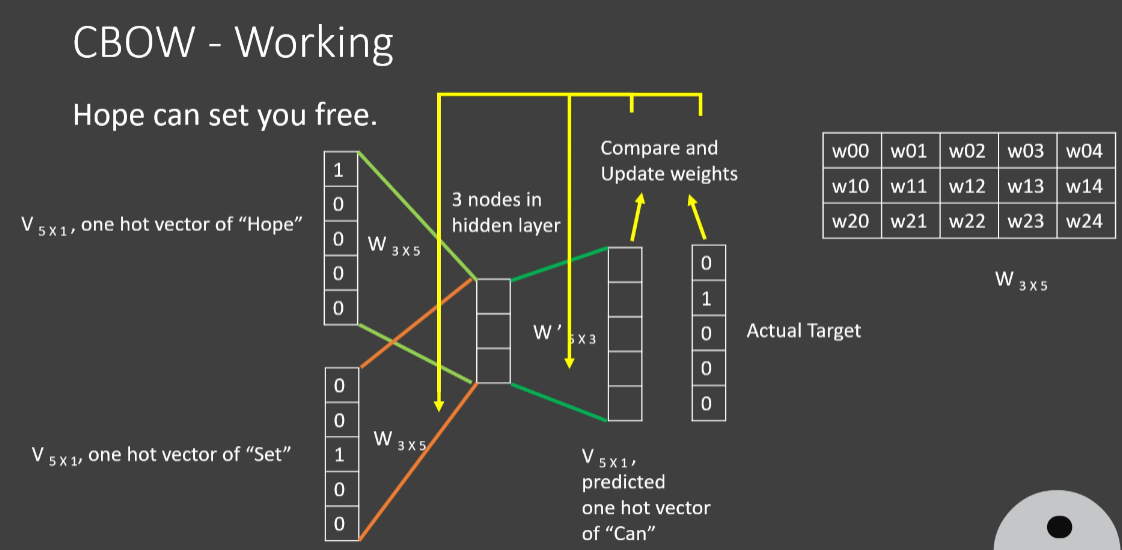 

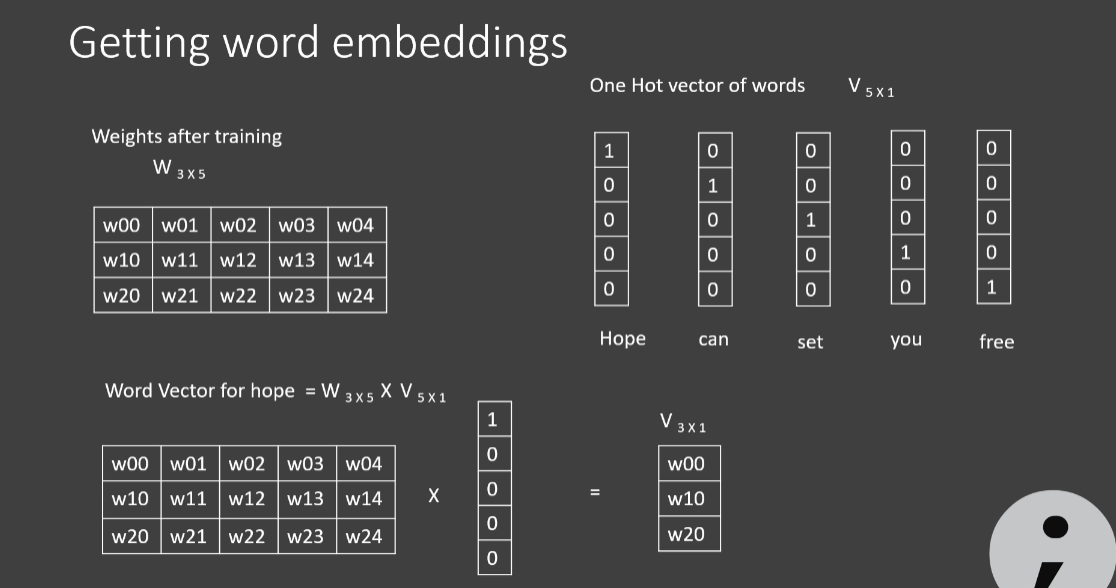 


CBoW will work well on small corpus is the faster of the two models

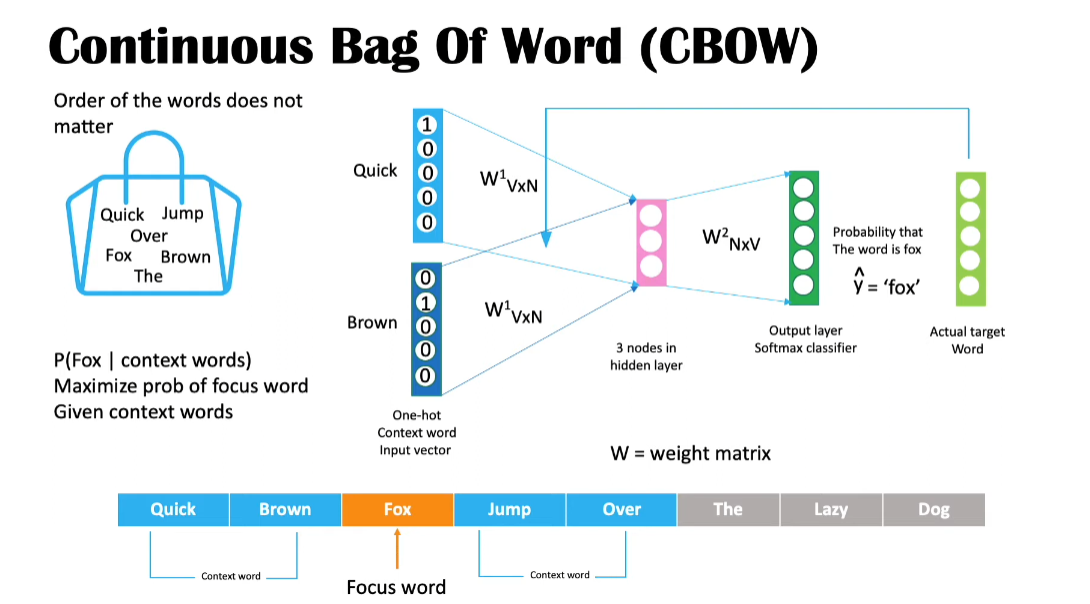 
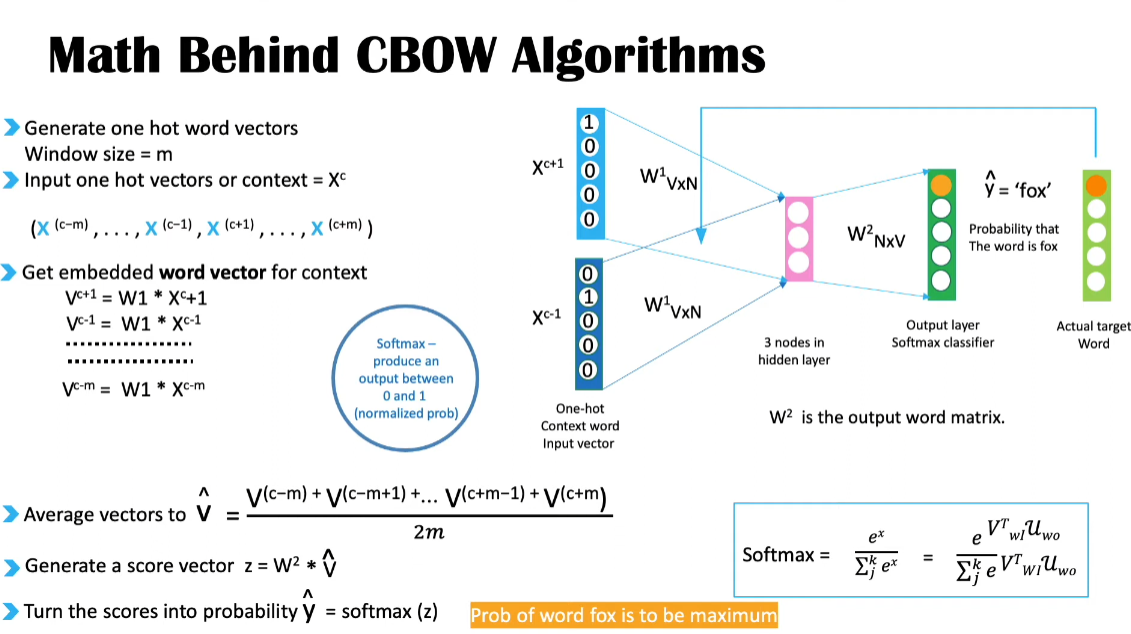 


## how it trains  


Forward Pass:
- **Input Layer:** The input to the model is a one-hot encoded representation of the context words. In the CBoW model, this is typically the average of the one-hot encoded context vectors.
  
- **Hidden Layer (Word Embedding Table):** The input is then multiplied by the **embedding matrix** to obtain the average of the embeddings of the context words. This is essentially a lookup in the embedding table, and the model learns the word vectors in the hidden layer.

- **Output Layer:** The output layer predicts the probability distribution over all words in the vocabulary (target word) using softmax.

 Backpropagation:
- After predicting the target word, the loss (typically cross-entropy loss) is calculated based on the difference between the predicted word distribution and the actual target word.
- Using backpropagation, the gradient of the loss is calculated with respect to the weights (which are the embeddings) and the softmax layer.
- The weights in the embedding matrix are then updated using gradient descent.

 **Updating the Embedding Table**
During backpropagation, the embedding vectors corresponding to the context words are updated to reduce the loss. These updates are gradually refined as the training progresses, adjusting the values in the embedding matrix so that similar words (appearing in similar contexts) end up with similar vectors.

 **Final Embedding Table**
After training, the embedding table contains meaningful word vectors that capture semantic and syntactic relationships between words. For example, words that appear in similar contexts (like "king" and "queen") will have similar embeddings, as the model learns to adjust the word vectors based on their contextual usage.



## Code implementation example : 


After converting our words in the corpus into vector of integers:
[[1, 5, 2, 1, 6, 3, 4, 7], [1, 8, 2, 1, 9, 3, 4, 10], [1, 11, 2, 1, 12, 3, 4, 13]]


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


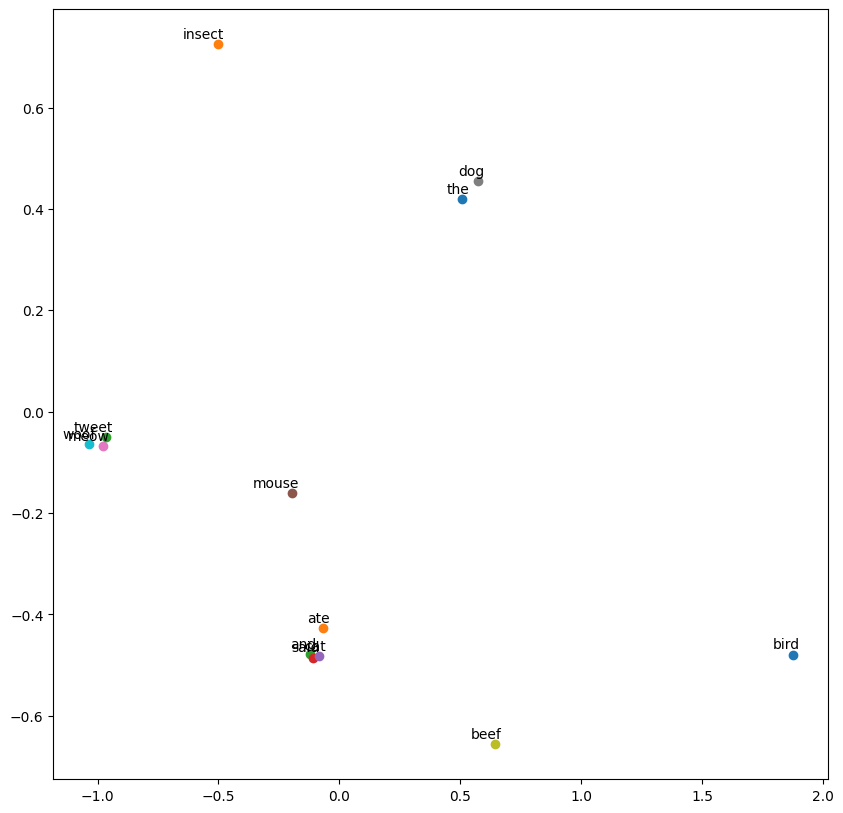

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Lambda
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


corpus = [
    'The cat ate the mouse and said meow',
    'The dog ate the beef and said woof',
    'The bird ate the insect and said tweet',
]

#Convert the corpus to a sequence of integers
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)
sequences = tokenizer.texts_to_sequences(corpus)
print("After converting our words in the corpus into vector of integers:")
print(sequences)

#Define the parameters
vocab_size = len(tokenizer.word_index) + 1
embedding_size = 10
window_size = 3

#Genrate the context-targetpairs
contexts = []
targets = []
for sequence in sequences:
    for i in range(window_size, len(sequence) - window_size):
        context = sequence[i - window_size:i] + sequence[i + 1:i + window_size + 1]
        target = sequence[i]
        contexts.append(context)
        targets.append(target)

#Convert the contexts and targets to numpy arrays
X = np.array(contexts)
y = np.array(targets)

# Define the CBOW model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_size, input_length=2 * window_size))
model.add(Lambda(lambda x: tf.reduce_mean(x, axis=1)))
model.add(Dense(units=vocab_size, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# Train the model (for demonstration purposes, we'll use 500 epochs to ensure the embeddings learn well)
model.fit(X, y, epochs=500, verbose=0)

# Save the model's weights
model.save_weights('cbow_weights.weights.h5')

# Load the pre-trained weights
model.load_weights('cbow_weights.weights.h5')

# Ensure the model has been trained
if len(model.get_weights()) > 0:
    # Get the embeddings from the embedding layer
    embeddings = model.get_weights()[0]

    # Perform PCA to reduce the dimensionality of the embeddings
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(embeddings)

    # Visualize the embeddings
    plt.figure(figsize=(10, 10))
    for i, word in enumerate(tokenizer.word_index.keys()):
        if i < len(reduced_embeddings):  # Ensure no index out of bounds
            x, y = reduced_embeddings[i]
            plt.scatter(x, y)
            plt.annotate(word, xy=(x, y), xytext=(5, 2),
                         textcoords='offset points',
                         ha='right', va='bottom')
    plt.show()
else:
    print("Model does not have weights yet. Please ensure the model is trained.")




**Softmax Function:**

* **Input:** A vector of K real numbers.
* **Output:** A probability distribution with K probabilities.
* **Normalization:** The output probabilities are proportional to the exponentials of the input numbers.
* **Range:** Each output component is between 0 and 1.
* **Sum:** The sum of all output components is 1.
* **Correspondence:** Larger input components correspond to larger output probabilities.

**Formal Definition:**

* **Function:** $\sigma: \mathbb{R}^K \rightarrow (0, 1)^K$
* **Input:** A vector $z = (z_1, ..., z_K) \in \mathbb{R}^K$
* **Output:** A vector $\sigma(z) \in (0, 1)^K$
* **Calculation:** Each component of $\sigma(z)$ is calculated as:
  $$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

**In essence, the softmax function transforms a vector of real numbers into a probability distribution, ensuring that the output values are valid probabilities and that the larger input values contribute more to the final probabilities.**


My written note on softmax example: 

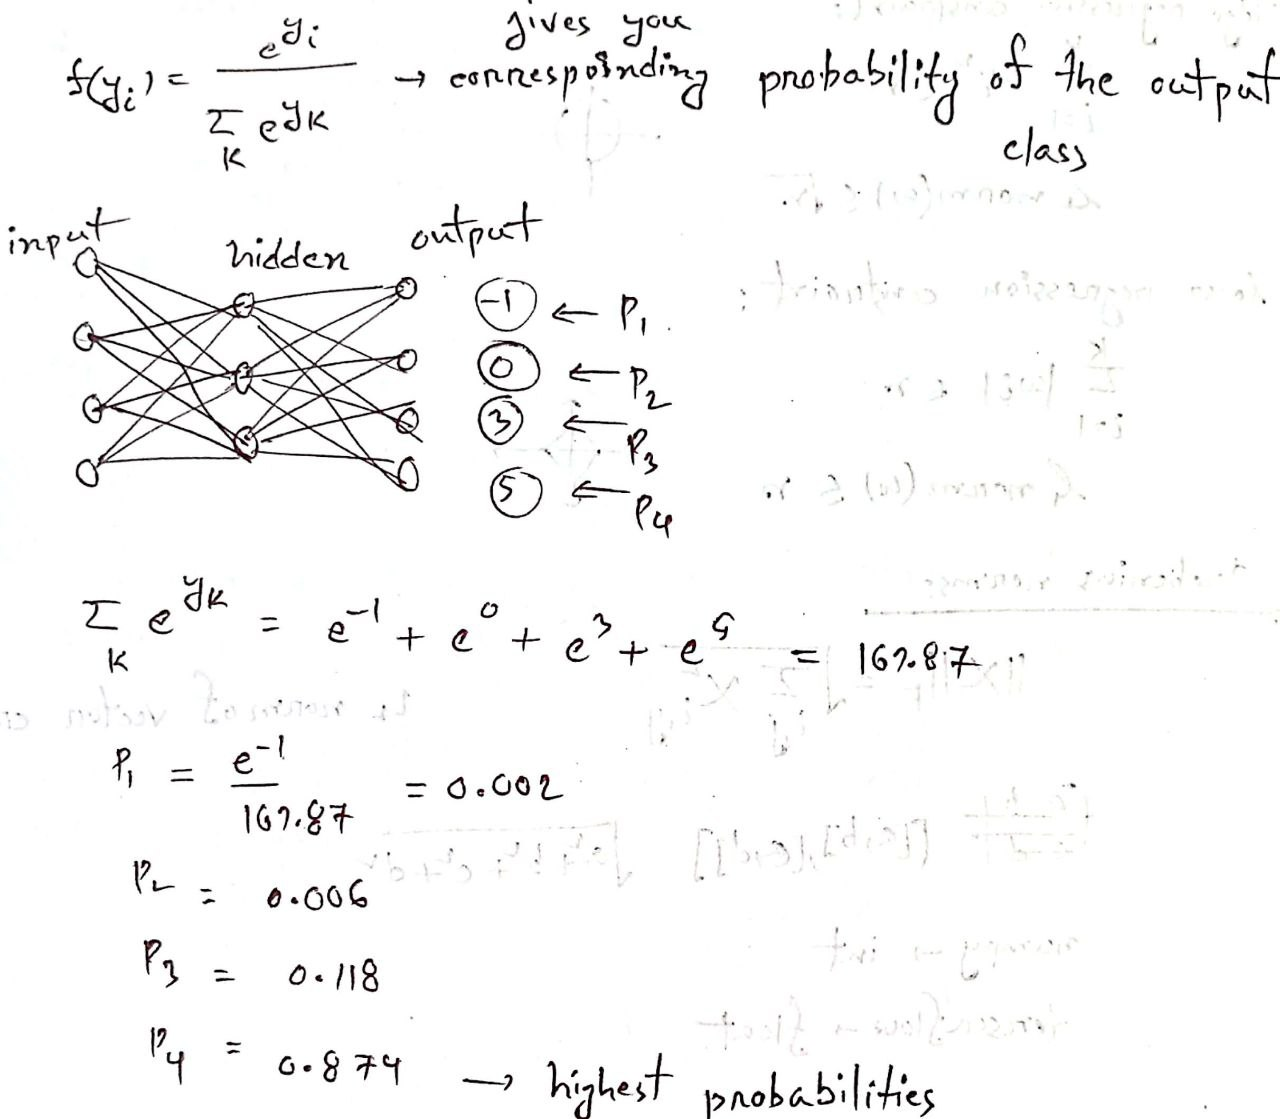

3D visalization : 
https://youtu.be/ytbYRIN0N4g?si=fxEH_1lZWcQqZuUq 

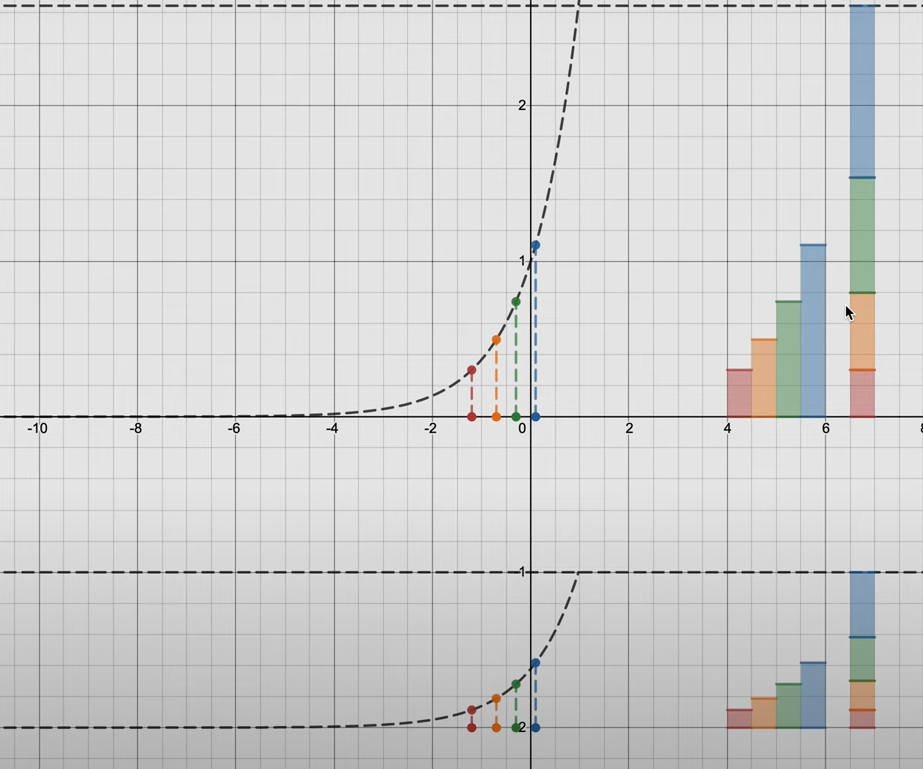

## Why cbow better than bag of words 
CBOW Captures the context of words by learning the meaning of words based on their surrounding words. It provides word embeddings that understand semantic relationships.
TF-IDF Does not understand the context in which a word appears. It only gives importance to a word based on how often it occurs in a document compared to the entire corpus, missing out on word meaning or relationships between words.





| Feature                   | CBOW                               | TF-IDF                                |
|---------------------------|------------------------------------|---------------------------------------|
| **Context Understanding**  | Learns meaning from surrounding words | Ignores context, purely based on frequency |
| **Dimensionality**         | Dense, low-dimensional embeddings  | Sparse, high-dimensional vectors      |
| **Synonym Handling**       | Groups similar words together      | Treats every word separately          |
| **Generalization**         | Works well with unseen data        | Poor with unseen data                 |
| **Word Importance**        | Context-based importance           | Frequency-based importance            |

